# GLFTMM Result Curves

Use `sim/report.py` to discover result folders and plot the curve for every folder.

In [ ]:
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path("/home/kang/glftmm")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

report_tools = importlib.import_module("sim.report")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 200)

Edit the variables below when you want a different symbol, date range, folder keyword, or plotting density.

In [ ]:
with open(REPO_ROOT / "config/config.json", "r", encoding="utf-8") as fh:
    CONFIG = json.load(fh)

ROOT_DIR = Path(CONFIG["paths"]["output_dir"])
SYMBOL = CONFIG.get("symbols", ["BTCUSDT"])[0]

# Use None for the full available range. Date format can be YYYY-MM-DD or YYYYMMDD.
SRT = None
END = None
EXCLUDE_DATE = None

# Optional folder-path substring filter, for example "md1" or "pg10x50".
KEYWORD = None

# Larger EVERY is faster and lighter. Set lower for smoother intraday curves.
EVERY = 600

# Cap points sent to matplotlib per run after EVERY sampling. Use None to disable.
MAX_PLOT_POINTS = 50_000

# PNL_ONLY=True plots only total PnL curves. False plots price/inventory/PnL/volume panels.
PNL_ONLY = False
NORMALIZE = False

# Plot folders in batches so each chart remains readable.
BATCH_SIZE = 6
NUM_WORKERS = 4

# Set to an integer while testing, for example 5. Use None for every discovered folder.
MAX_FOLDERS = None

ROOT_DIR, SYMBOL

Discover every leaf folder that contains matching parquet reports.

In [ ]:
folders, counts = report_tools.get_folders_with_counts(
    ROOT_DIR,
    SYMBOL,
    srt=SRT,
    end=END,
    exclude_date=EXCLUDE_DATE,
    keyword=KEYWORD,
)

folder_df = pd.DataFrame(
    {
        "run_id": np.arange(len(folders), dtype=int),
        "file_count": counts,
        "folder": folders,
    }
)

def run_name(folder: str | Path) -> str:
    path = Path(folder)
    if path.name == "strat__all" and path.parent.name:
        return path.parent.name
    return path.name

if not folder_df.empty:
    folder_df.insert(1, "run_name", folder_df["folder"].map(run_name))

print(f"found {len(folder_df)} folders under {ROOT_DIR}")
display(folder_df)

if folder_df.empty:
    raise FileNotFoundError(
        f"no report parquet folders found under {ROOT_DIR} for symbol={SYMBOL}, keyword={KEYWORD}"
    )

Helper functions for selecting folders and calling `report_tools.report(...)`.

In [ ]:
def choose_folders(
    indices: list[int] | tuple[int, ...] | None = None,
    contains: str | None = None,
    limit: int | None = MAX_FOLDERS,
) -> pd.DataFrame:
    df = folder_df.copy()
    if contains is not None:
        df = df[df["folder"].str.contains(contains, regex=False)]
    if indices is not None:
        wanted = list(indices)
        df = df[df["run_id"].isin(wanted)]
        df = df.set_index("run_id").reindex(wanted).dropna(subset=["folder"]).reset_index()
    if limit is not None:
        df = df.head(int(limit))
    return df.reset_index(drop=True)


def plot_folder_batch(
    df: pd.DataFrame,
    *,
    pnl_only: bool = PNL_ONLY,
    every: int = EVERY,
    normalize: bool = NORMALIZE,
    max_plot_points: int | None = MAX_PLOT_POINTS,
) -> pd.DataFrame:
    if df.empty:
        raise ValueError("empty folder selection")

    folders_to_plot = df["folder"].tolist()
    labels = [f"{int(run_id):03d}" for run_id in df["run_id"]]

    stats = report_tools.report(
        folders_to_plot,
        every=every,
        pnl_only=pnl_only,
        srt=SRT,
        end=END,
        exclude_date=EXCLUDE_DATE,
        labels=labels,
        normalize=normalize,
        num_workers=NUM_WORKERS,
        max_plot_points=max_plot_points,
    )

    metrics = pd.DataFrame(stats)
    metrics.insert(0, "run_id", labels[: len(metrics)])
    metrics.insert(1, "file_count", df["file_count"].to_list()[: len(metrics)])
    metrics.insert(2, "folder", folders_to_plot[: len(metrics)])
    display(metrics)
    return metrics

Plot every discovered folder, split into batches.

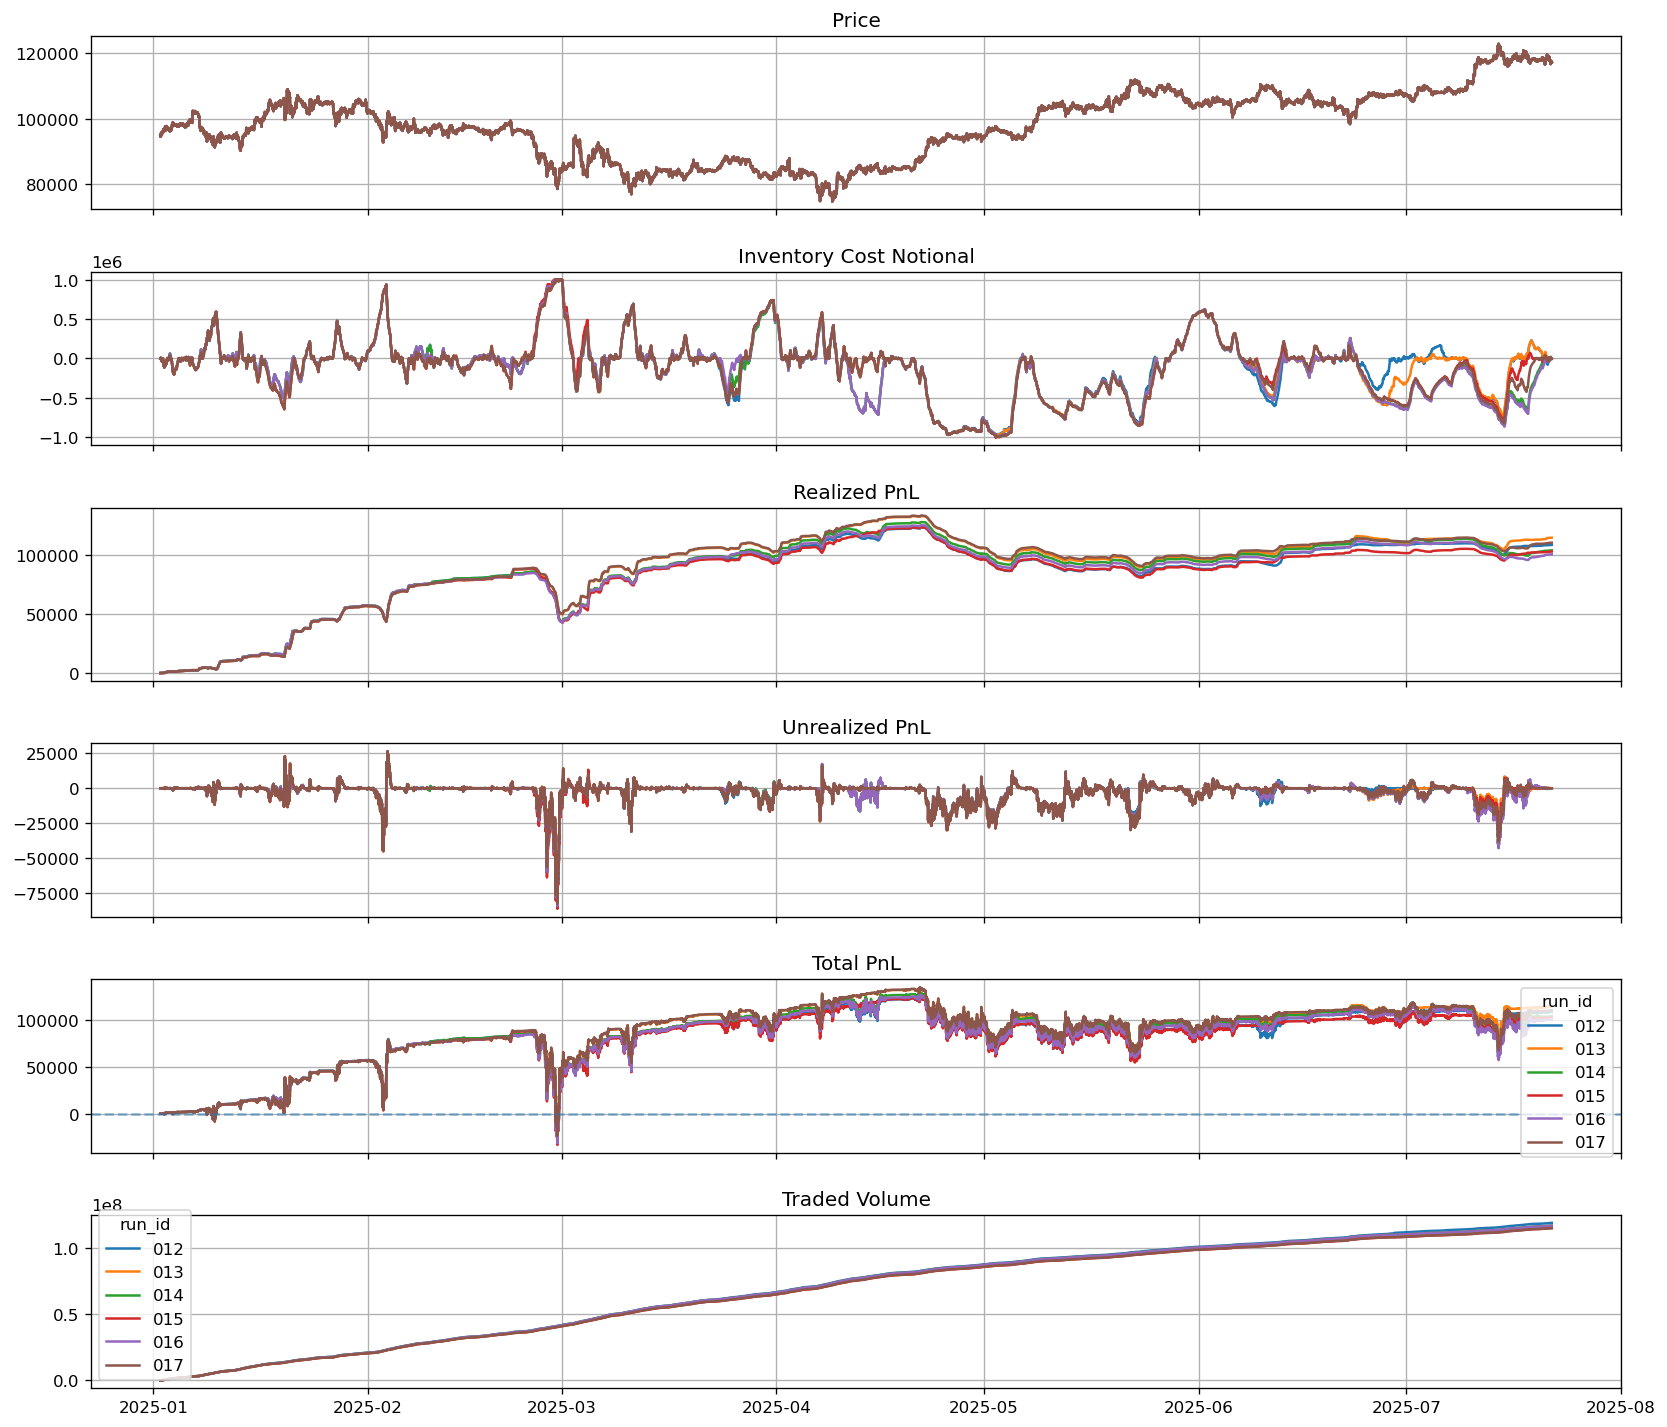

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,012,201,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk50x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,108780.141785,0.072654,3.120548,62984.384834,196545.809420,3.120548,0.072654,588869.098832,0.000916
1,013,201,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk50x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,114863.249076,0.077826,3.117145,66621.179326,207667.856631,3.117145,0.077826,573965.767649,0.000993
2,014,201,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk50x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,104112.408170,0.067520,2.939238,63971.407688,188027.195571,2.939238,0.067520,578585.409819,0.000893
3,015,201,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk50x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,103129.059852,0.067837,2.778363,67036.953599,186252.961297,2.778363,0.067837,569260.007965,0.000899
4,016,200,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk50x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,100755.598931,0.065259,2.845267,63931.084108,181901.018710,2.845267,0.065259,578561.038343,0.000864
5,017,201,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2p5x2p5__asv0x0__bp0x1__bu1x0p2__cc5x5x1__cdt0__fr1000__isk50x1__lat2__lbi300__mfm3em05__mhtm1__mp1000000__mon100...,110638.649350,0.073148,2.976334,67182.629793,199957.962131,2.976334,0.073148,568983.281254,0.000964


batch 4: run_id 018..023


In [ ]:
plot_df = choose_folders(limit=MAX_FOLDERS)
all_metrics = []

for start in range(0, len(plot_df), BATCH_SIZE):
    batch = plot_df.iloc[start : start + BATCH_SIZE]
    first_id = int(batch["run_id"].iloc[0])
    last_id = int(batch["run_id"].iloc[-1])
    print(f"batch {start // BATCH_SIZE + 1}: run_id {first_id:03d}..{last_id:03d}")
    all_metrics.append(plot_folder_batch(batch))

summary_df = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
display(summary_df.sort_values("pnls", ascending=False).reset_index(drop=True))

In [ ]:
folders[31]

In [ ]:
folders[35]

Inspect one folder with the full report panels.

Compare selected folders on one PnL chart.